# Explore SFS

**Reviewer's comment:**

*The supervised deep learning model is trained on simulations based on a demographic model assumed to be neutral. New simulations with varying introgression levels (5–50%, line 678) were generated using msmodified.*

*How realistic is the demographic model if it does not inherently include introgression?*

*Could the authors provide evidence that the site frequency spectrum (SFS) from the simulated data matches the observed SFS (using samples not included when building the demographic model)?*

### Get FS file of each pair's introgressed regions in each direction

In [ ]:
pop1='wel'
pop1='sel'
pop2='lpa'

# intersect VCF with introgressed regions
for intro in ${pop1}_to_${pop2} ${pop2}_to_${pop1}; do
    bed=data/introgression_scans/bed_files/${intro}_intro.merged.bed
    vcf=data/lynxtrogression_v2.autosomic_scaffolds.filter4.${pop2}-${pop1}.ps.phased.merged.concat.fixed.afan.rd_fil.variant.vcf
    out=data/${intro}.merged.vcf
    echo "Processing ${intro}..."
    bedtools intersect -header -a ${vcf} -b ${bed} -wa > ${out}
done

# make SFS from VCFs
for intro in ${pop1}_to_${pop2} ${pop2}_to_${pop1}; do
    echo "Making SFS for ${intro}..."
    ivcf=data/${intro}.merged.vcf
    pair=${pop2}-${pop1}
    python src/demographic_inference/make_fs_from_vcf.py \
        --ivcf ${ivcf} \
        --popinfo data/demographic_inference/${pair}.popmap.txt \
        --ofs data/demographic_inference/${pair}_${intro}.fs
done

### Concatenate simulations of each pair's introgressed regions in each direction

In [44]:
import dadi
import numpy as np
import gzip
import pylab

# pop_pair options: "lpa-wel" or "lpa-sel"
# pop_pair = "lpa-sel"
pop_pair = "lpa-wel"

if pop_pair == "lpa-wel":
    models = ["6_2", "12_9", "20_7"]
elif pop_pair == "lpa-sel":
    models = ["12_6", "18_7", "18_10"]

# options for mig: "ab", "ba", "none"
# mig = "ab"
mig = "ba"
# mig = "none"

ms_file = f"data/introgression_scans/simulations_withM/{pop_pair}.{mig}.concatenated.msOut"
print(ms_file)

data/introgression_scans/simulations_withM/lpa-wel.ba.concatenated.msOut


without bi sims in ab and ba

In [ ]:
# concatenate all msOut.gz files into a single msOut file
first_file = True
with open(ms_file, 'w') as f_out:
    if mig == "ab" or mig == "ba" or mig == "none":
        for model in models:
            gzms_file = f"data/introgression_scans/simulations_withM/{pop_pair}_{mig}_filtered_sims/{model}/mig.msOut.gz"
            with gzip.open(gzms_file, 'rt') as f_in:
                lines = f_in.readlines()
                if first_file:
                    f_out.writelines(lines)
                    first_file = False
                else:
                    f_out.writelines(lines[2:-1])  # Skip first 3 lines and last line
    elif mig == "bi":
        for bimig in ["abba", "baab"]:
            for model in models:
                gzms_file = f"data/introgression_scans/simulations_withM/{pop_pair}_{mig}_filtered_sims/{model}_{bimig}/mig.msOut.gz"
                with gzip.open(gzms_file, 'rt') as f_in:
                    lines = f_in.readlines()
                    if first_file:
                        f_out.writelines(lines)
                        first_file = False
                    else:
                        f_out.writelines(lines[2:-1])  # Skip first 3 lines and last line
print(f"Concatenation complete to {ms_file}")

with bi sims in ab and ba (more similar to how intro is called with real data)

In [45]:
# concatenate all msOut.gz files into a single msOut file
first_file = True
with open(ms_file, 'w') as f_out:
    if mig == "ab" or mig == "ba" or mig == "none":
        for model in models:
            gzms_file = f"data/introgression_scans/simulations_withM/{pop_pair}_{mig}_filtered_sims/{model}/mig.msOut.gz"
            with gzip.open(gzms_file, 'rt') as f_in:
                lines = f_in.readlines()
                if first_file:
                    f_out.writelines(lines)
                    first_file = False
                else:
                    f_out.writelines(lines[2:-1])  # Skip first 3 lines and last line
            for bimig in ["abba", "baab"]:
                gzms_file = f"data/introgression_scans/simulations_withM/{pop_pair}_bi_filtered_sims/{model}_{bimig}/mig.msOut.gz"
                with gzip.open(gzms_file, 'rt') as f_in:
                    lines = f_in.readlines()
                    if first_file:
                        f_out.writelines(lines)
                        first_file = False
                    else:
                        f_out.writelines(lines[2:-1])  # Skip first 3 lines and last line
    elif mig == "none":
        for model in models:
            gzms_file = f"data/introgression_scans/simulations_withM/{pop_pair}_{mig}_filtered_sims/{model}/mig.msOut.gz"
            with gzip.open(gzms_file, 'rt') as f_in:
                lines = f_in.readlines()
                if first_file:
                    f_out.writelines(lines)
                    first_file = False
                else:
                    f_out.writelines(lines[2:-1])  # Skip first 3 lines and last line

print(f"Concatenation complete to {ms_file}")

Concatenation complete to data/introgression_scans/simulations_withM/lpa-wel.ba.concatenated.msOut


### Plot 2D-SFS for Real Data v Simulations

In each introgression scenario (ab ba none) for each population pair (lpa-wel and lpa-sel)

In [46]:
if mig == "ab" and pop_pair == "lpa-wel":
    scenario = 'wel_to_lpa'
elif mig == "ba" and pop_pair == "lpa-wel":
    scenario = 'lpa_to_wel'
elif mig == "ab" and pop_pair == "lpa-sel":
    scenario = 'sel_to_lpa'
elif mig == "ba" and pop_pair == "lpa-sel":
    scenario = 'lpa_to_sel'
elif mig == "none":
    scenario = 'real_data'

print(f"Scenario: {scenario}")
data_file = f"data/demographic_inference/{pop_pair}_{scenario}.fs"

Scenario: lpa_to_wel


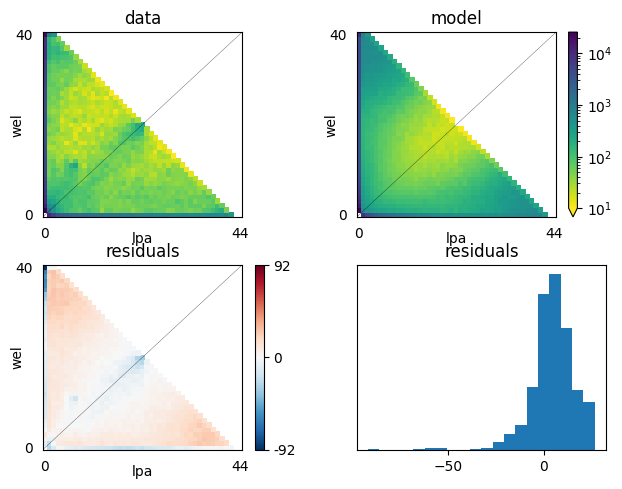

In [47]:
ms_data = dadi.Spectrum.from_ms_file(ms_file, average=True, mask_corners=True)
# mask [0, 0], [0, n2] and [n1, 0] and [n1, n2]
ms_data.mask[0, 0] = True
#ms_data.mask[0, ms_data.sample_sizes[1]] = True
#ms_data.mask[ms_data.sample_sizes[0], 0] = True
ms_data.mask[ms_data.sample_sizes[0], ms_data.sample_sizes[1]] = True
folded_data = ms_data.fold()
real_data = dadi.Spectrum.from_file(data_file, mask_corners=True)
# mask [0, 0], [0, n2] and [n1, 0] and [n1, n2]
real_data.mask[0, 0] = True
#real_data.mask[0, real_data.sample_sizes[1]] = True
#real_data.mask[real_data.sample_sizes[0], 0] = True
real_data.mask[real_data.sample_sizes[0], real_data.sample_sizes[1]] = True
dadi.Plotting.plot_2d_comp_multinom(model = folded_data, data = real_data, vmin = 10)

Scenario: wel_to_lpa


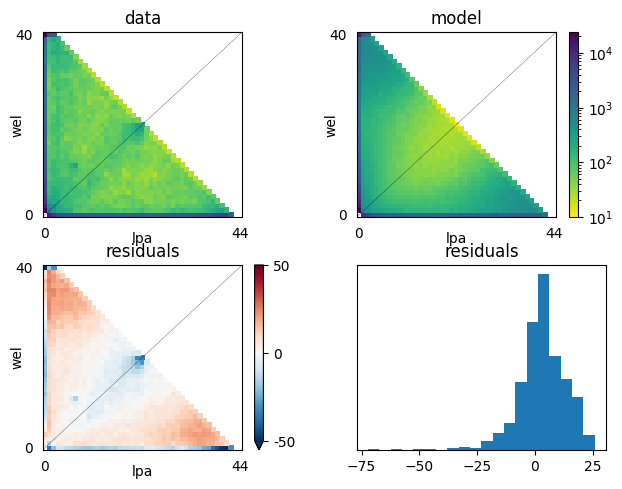

Scenario: lpa_to_wel


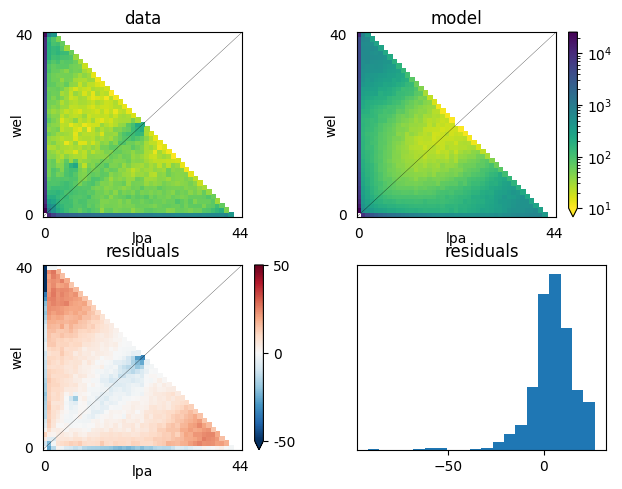

Scenario: real_data


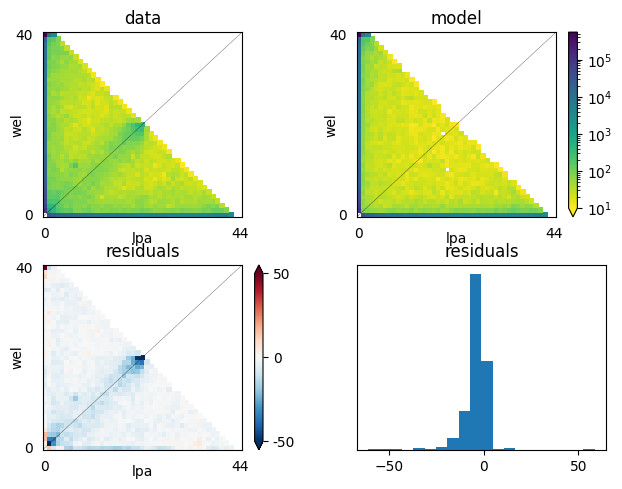

Scenario: sel_to_lpa


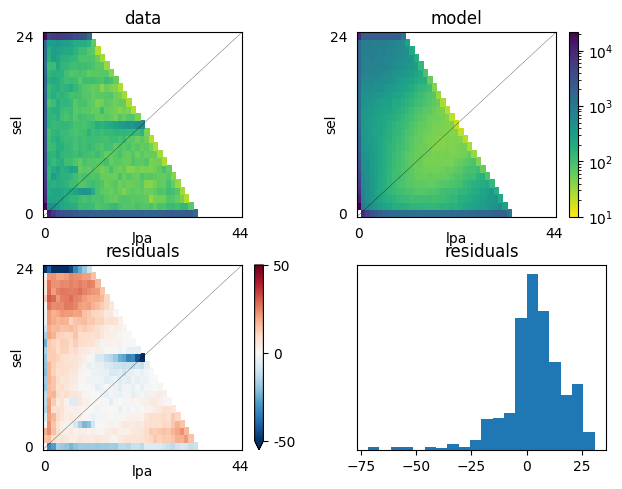

Scenario: lpa_to_sel


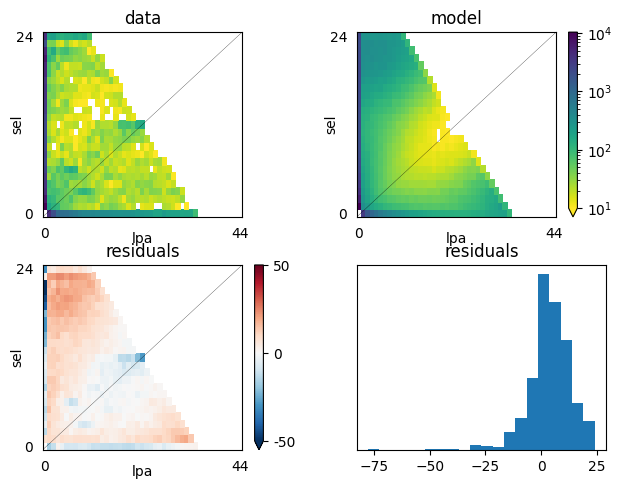

Scenario: real_data


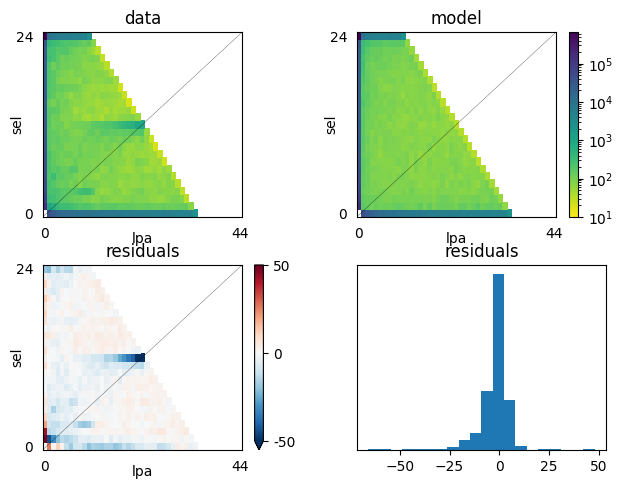

In [49]:
# all in a loop for each pop_pair and mig direction
for pop_pair in ["lpa-wel", "lpa-sel"]:
    for mig in ["ab", "ba", "none"]:
        if mig == "ab" and pop_pair == "lpa-wel":
            scenario = 'wel_to_lpa'
        elif mig == "ba" and pop_pair == "lpa-wel":
            scenario = 'lpa_to_wel'
        elif mig == "ab" and pop_pair == "lpa-sel":
            scenario = 'sel_to_lpa'
        elif mig == "ba" and pop_pair == "lpa-sel":
            scenario = 'lpa_to_sel'
        elif mig == "none":
            scenario = 'real_data'

        print(f"Scenario: {scenario}")
        ms_file = f"data/introgression_scans/simulations_withM/{pop_pair}.{mig}.concatenated.msOut"
        data_file = f"data/demographic_inference/{pop_pair}_{scenario}.fs"
        
        ms_data = dadi.Spectrum.from_ms_file(ms_file, average=True, mask_corners=True)
        # mask [0, 0], [0, n2] and [n1, 0] and [n1, n2]
        ms_data.mask[0, 0] = True
        # ms_data.mask[0, ms_data.sample_sizes[1]] = True
        # ms_data.mask[ms_data.sample_sizes[0], 0] = True
        ms_data.mask[ms_data.sample_sizes[0], ms_data.sample_sizes[1]] = True
        folded_data = ms_data.fold()
        real_data = dadi.Spectrum.from_file(data_file, mask_corners=True)
        # mask [0, 0], [0, n2] and [n1, 0] and [n1, n2]
        real_data.mask[0, 0] = True
        # real_data.mask[0, real_data.sample_sizes[1]] = True
        # real_data.mask[real_data.sample_sizes[0], 0] = True
        real_data.mask[real_data.sample_sizes[0], real_data.sample_sizes[1]] = True
        fig = pylab.figure(1)
        fig.clear()
        dadi.Plotting.plot_2d_comp_multinom(model = folded_data, data = real_data, vmin = 10, resid_range = 50)
        fig.savefig(f"plots/demographic_inference/revision_1/{pop_pair}_{mig}_2d_sfs_comparison.pdf")